# **Landmark Transformer model for Character-level hand sign detection**

## Setup

In [33]:
import torch
import torch.nn as nn
from torch import optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from typing import Tuple, Dict, List
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from sklearn.model_selection import train_test_split
import cv2
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import seaborn as sns

sys.path.insert(0, '..')

In [34]:
config = {
    'batch_size': 128,
    'num_epochs': 30,
    'learning_rate': 0.0001,
    'dropout_rate': 0.1,
    'd_model': 512,
    'num_heads': 4,
    'encoder_layers': 3,
    'num_classes': 0,  # To be set after loading data
}

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Prep

### Data Exploration

In [36]:
labels_df_0 = pd.read_csv('../dataset/labels.csv')
labels_df = pd.read_parquet('../dataset/labels_with_landmarks_v2.parquet')

In [37]:
labels_df_0.shape, labels_df.shape

((107260, 2), (107260, 4))

In [38]:
labels_df.head(3)

,image,label,landmarks_flat,normalized_landmarks_flat
0,asl-0-augmented-0.jpg,del,"[0.3998647630214691, 0.3238876163959503, 1.973...","[0.0, 0.0, 0.0, 0.3552599221777102, 0.15436393..."
1,asl-0-augmented-1.jpg,del,"[0.5381386280059814, 0.10483518242835999, 1.00...","[0.0, 0.0, 0.0, 0.09607725194118076, 0.0151670..."
2,asl-0-augmented-2.jpg,del,"[0.6720114946365356, 0.4920685291290283, 9.840...","[0.0, 0.0, 0.0, -0.08181251538453072, 0.021777..."


In [39]:
# delete _flat from column names
labels_df = labels_df.rename(columns={
    'landmarks_flat': 'landmarks', 
    'normalized_landmarks_flat': 'normalized_landmarks'
})

In [40]:
labels_df.head(3)

,image,label,landmarks,normalized_landmarks
0,asl-0-augmented-0.jpg,del,"[0.3998647630214691, 0.3238876163959503, 1.973...","[0.0, 0.0, 0.0, 0.3552599221777102, 0.15436393..."
1,asl-0-augmented-1.jpg,del,"[0.5381386280059814, 0.10483518242835999, 1.00...","[0.0, 0.0, 0.0, 0.09607725194118076, 0.0151670..."
2,asl-0-augmented-2.jpg,del,"[0.6720114946365356, 0.4920685291290283, 9.840...","[0.0, 0.0, 0.0, -0.08181251538453072, 0.021777..."


In [41]:
labels_df['landmarks'][0].dtype, labels_df['landmarks'][0].shape, labels_df['normalized_landmarks'][0].dtype, labels_df['normalized_landmarks'][0].shape

(dtype('float64'), (63,), dtype('float64'), (63,))

In [42]:
labels_df['label'].nunique()

39

In [43]:
config['num_classes'] = labels_df['label'].nunique()

In [44]:
labels_df['label'].value_counts()

label
v          3456
d          3440
z          3432
u          3332
l          3324
o          3316
t          3312
y          3220
s          3208
a          3204
k          3112
x          3112
q          3092
j          3084
f          3072
p          3056
e          3044
i          2996
r          2992
2          2980
3          2960
n          2960
c          2952
g          2940
w          2864
m          2780
7          2696
0          2668
8          2644
4          2592
b          2552
5          2552
h          2552
9          2516
1          2452
6          2436
nothing     120
space       120
del         120
Name: count, dtype: int64

### Integrating Mediapipe landmark detection

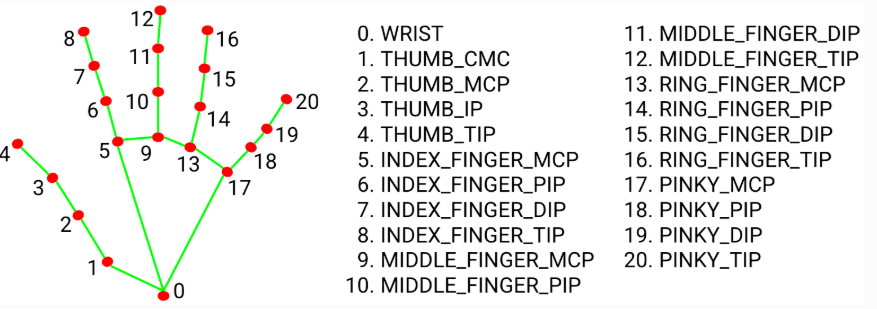

- Preprocessing: Wrist-Centric Normalization & Scale Invariance

In [45]:
def normalize_landmarks(landmarks):
    # landmarks shape: (21, 3)
    wrist = landmarks[0]
    
    # Wrist centering
    centered = landmarks - wrist
    
    # Scale normalization
    # Calculate Euclidean distance for all points from the new origin
    distances = np.linalg.norm(centered, axis=1)
    max_dist = np.max(distances)
    
    # Avoid division by zero
    if max_dist == 0:
        return centered
        
    normalized = centered / max_dist
    return normalized

Landmarks detected!
<class 'mediapipe.tasks.python.components.containers.landmark.NormalizedLandmark'>
NormalizedLandmark(x=0.3998647630214691, y=0.3238876163959503, z=1.9731791667254583e-07, visibility=None, presence=None, name=None)
21


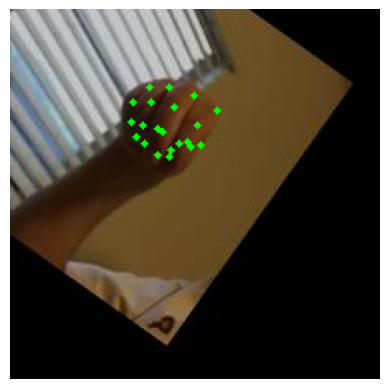

Original landmarks: [[ 3.99864763e-01  3.23887616e-01  1.97317917e-07]
 [ 4.78714228e-01  3.58148485e-01 -4.60653529e-02]
 [ 5.13942540e-01  3.66214484e-01 -8.83370042e-02]
 [ 4.88233775e-01  3.73510182e-01 -1.27053440e-01]
 [ 4.33349371e-01  3.83918643e-01 -1.65612340e-01]
 [ 5.58426619e-01  2.72547245e-01 -9.42052305e-02]
 [ 5.05591989e-01  3.15575391e-01 -1.48431167e-01]
 [ 4.57452506e-01  3.63283783e-01 -1.83742285e-01]
 [ 4.29104179e-01  4.00077075e-01 -2.06400946e-01]
 [ 4.97594774e-01  2.33903974e-01 -9.93330702e-02]
 [ 4.43622947e-01  2.63792545e-01 -1.54477924e-01]
 [ 4.10894930e-01  3.33772182e-01 -1.71550065e-01]
 [ 3.98604751e-01  3.93537641e-01 -1.81175396e-01]
 [ 4.32339728e-01  2.13382453e-01 -1.06809497e-01]
 [ 3.80496085e-01  2.53760248e-01 -1.56143084e-01]
 [ 3.61418337e-01  3.16728950e-01 -1.55336350e-01]
 [ 3.62686515e-01  3.65757227e-01 -1.48630917e-01]
 [ 3.76308382e-01  2.10410774e-01 -1.18687660e-01]
 [ 3.33444595e-01  2.53323257e-01 -1.45736933e-01]
 [ 3.299672

In [46]:
# try using mediapipe to extract landmarks from an image and test the normalization function
landmarker_path = '../hand_landmarker/hand_landmarker.task'
base_options = python.BaseOptions(model_asset_path=landmarker_path)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

image_path = '../dataset/images/' + labels_df['image'].iloc[2000]
img = mp.Image.create_from_file(image_path)
results = detector.detect(img)
landmarks = []
if results.hand_landmarks:
    print("Landmarks detected!")
    print(type(results.hand_landmarks[0][0]))
    print(results.hand_landmarks[0][0])
    print(len(results.hand_landmarks[0]))

    for lm in results.hand_landmarks[0]:
        # print(lm.x, lm.y, lm.z)
        landmarks.append([lm.x, lm.y, lm.z])

    # visualize the landmarks
    img_cv = cv2.imread(image_path)
    for lm in results.hand_landmarks[0]:
        x = int(lm.x * img_cv.shape[1])
        y = int(lm.y * img_cv.shape[0])
        cv2.circle(img_cv, (x, y), 2, (0, 255, 0), -1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

landmarks = np.array(landmarks)
print("Original landmarks:", landmarks)
normalized_landmarks = normalize_landmarks(landmarks)
print("Normalized landmarks:", normalized_landmarks)

In [47]:
classes = labels_df['label'].unique()
label_map = {label: idx for idx, label in enumerate(classes)}
inverse_label_map = {idx: label for label, idx in label_map.items()}
print("Label map:", label_map)
print("Inverse label map:", inverse_label_map)

Label map: {'del': 0, 'nothing': 1, 'space': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12, 'k': 13, 'l': 14, 'm': 15, 'n': 16, 'o': 17, 'p': 18, 'q': 19, 'r': 20, 's': 21, 't': 22, 'u': 23, 'v': 24, 'w': 25, 'x': 26, 'y': 27, 'z': 28, '0': 29, '1': 30, '2': 31, '3': 32, '4': 33, '5': 34, '6': 35, '7': 36, '8': 37, '9': 38}
Inverse label map: {0: 'del', 1: 'nothing', 2: 'space', 3: 'a', 4: 'b', 5: 'c', 6: 'd', 7: 'e', 8: 'f', 9: 'g', 10: 'h', 11: 'i', 12: 'j', 13: 'k', 14: 'l', 15: 'm', 16: 'n', 17: 'o', 18: 'p', 19: 'q', 20: 'r', 21: 's', 22: 't', 23: 'u', 24: 'v', 25: 'w', 26: 'x', 27: 'y', 28: 'z', 29: '0', 30: '1', 31: '2', 32: '3', 33: '4', 34: '5', 35: '6', 36: '7', 37: '8', 38: '9'}


In [48]:
class LandmarkDataset(Dataset):
    def __init__(self, labels_df, img_dir, detector, label_map):
        self.labels_df = labels_df
        self.img_dir = img_dir
        self.detector = detector
        self.label_map = label_map

    def __len__(self):
        return len(self.labels_df)
    
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = f"{self.img_dir}/{row['image']}"
        label = row['label']
        label_idx = self.label_map[label]
        label_idx = torch.tensor(label_idx, dtype=torch.long)
        
        # Load image and extract landmarks
        try:
            image = mp.Image.create_from_file(img_path)
            results = self.detector.detect(image)
        except Exception as e:
            print(f"Error occurred while processing image {img_path}: {e}")
            return torch.zeros((21, 3), dtype=torch.float32), label_idx

        if results.hand_landmarks:
            landmarks = []
            for lm in results.hand_landmarks[0]:
                landmarks.append([lm.x, lm.y, lm.z])
            landmarks = np.array(landmarks)
            normalized_landmarks = normalize_landmarks(landmarks)
            return torch.tensor(normalized_landmarks, dtype=torch.float32), label_idx
        else:
            # If no hand detected, return zeros
            return torch.zeros((21, 3), dtype=torch.float32), label_idx

In [49]:
class LandmarkDatasetWithLandmarks(Dataset):
    def __init__(self, labels_df, label_map):
        self.labels_df = labels_df
        self.label_map = label_map

    def __len__(self):
        return len(self.labels_df)
    
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        label = row['label']
        label_idx = self.label_map[label]
        label_idx = torch.tensor(label_idx, dtype=torch.long)

        landmarks = row['landmarks']
        landmarks = np.array(landmarks)
        landmarks = landmarks.reshape(21, 3)  # Ensure landmarks are in the correct

        normalized_landmarks = row['normalized_landmarks']
        normalized_landmarks = np.array(normalized_landmarks)
        normalized_landmarks = normalized_landmarks.reshape(21, 3)  # Ensure normalized_landmarks are in the correct shape
        return torch.tensor(normalized_landmarks, dtype=torch.float32), torch.tensor(landmarks, dtype=torch.float32), label_idx

In [50]:
"""
Train Val Test split
70 15 15 split
"""
train_df, temp_df = train_test_split(
    labels_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=labels_df['label'] 
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

# train_dataset = LandmarkDataset(train_df, '../dataset/images', detector, label_map)
# val_dataset = LandmarkDataset(val_df, '../dataset/images', detector, label_map)
# test_dataset = LandmarkDataset(test_df, '../dataset/images', detector, label_map)

train_dataset = LandmarkDatasetWithLandmarks(train_df, label_map)
val_dataset = LandmarkDatasetWithLandmarks(val_df, label_map)          
test_dataset = LandmarkDatasetWithLandmarks(test_df, label_map)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

Train size: 75082 | Val size: 16089 | Test size: 16089


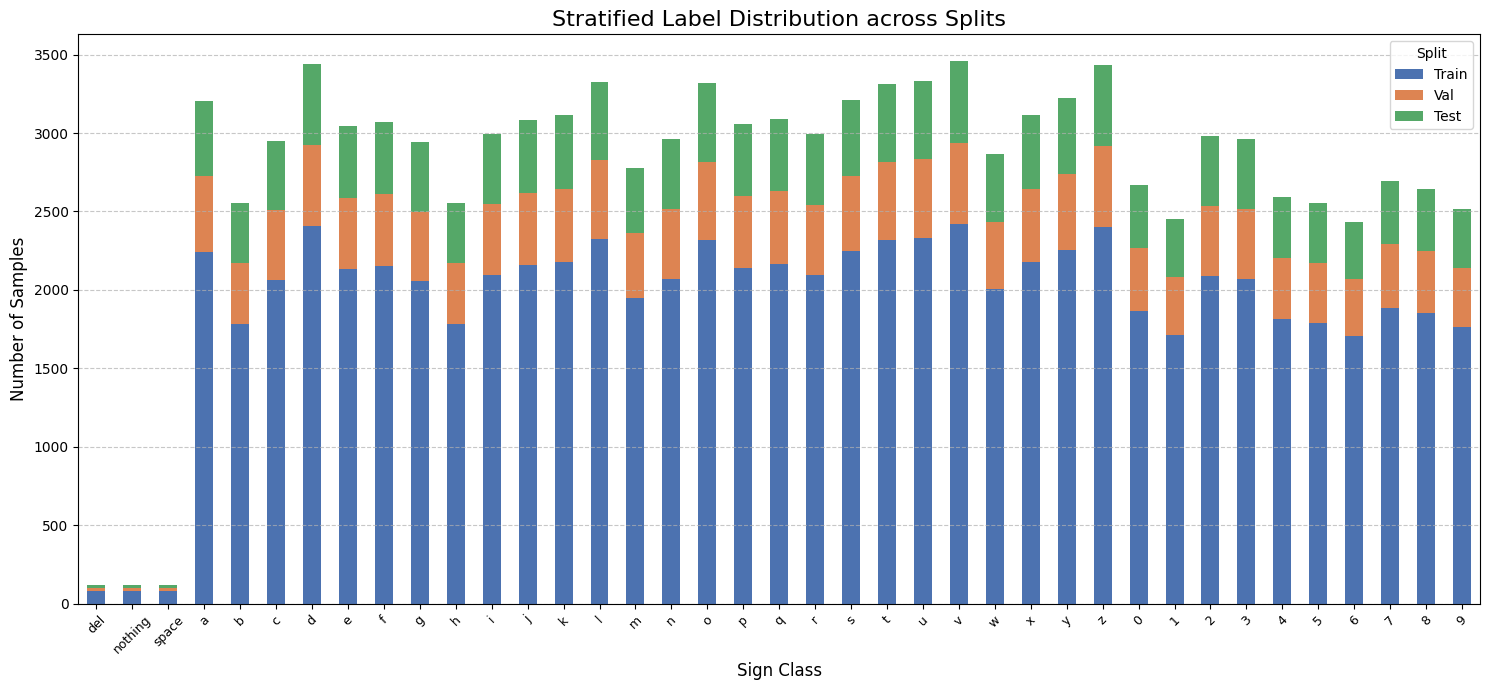

In [51]:
def plot_label_distribution(train_df, val_df, test_df, label_map, save_path=None):
    # 1. Create a combined DataFrame for automatic alignment
    # This ensures that even if a class is missing in Val, it gets a 0 instead of shifting the plot
    df_counts = pd.DataFrame({
        'Train': train_df['label'].value_counts(),
        'Val': val_df['label'].value_counts(),
        'Test': test_df['label'].value_counts()
    }).fillna(0)

    # 2. Sort by the order of your label_map (Optional, but keeps 'A' to 'Z' logical)
    # We use the keys of label_map to ensure the order 0, 1, 2...
    order = [label_map[i] for i in sorted(label_map.keys())]
    df_counts = df_counts.reindex(order)

    # 3. Plotting as a Stacked Bar
    # This is much better for showing "Parts of a Whole" for your report
    ax = df_counts.plot(kind='bar', stacked=True, figsize=(15, 7), color=['#4C72B0', '#DD8452', '#55A868'])
    
    plt.title('Stratified Label Distribution across Splits', fontsize=16)
    plt.xlabel('Sign Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45, fontsize=9)
    plt.legend(title="Split")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# Use it like this
plot_label_distribution(train_df, val_df, test_df, inverse_label_map, save_path='../results/label_distribution_stacked.png')

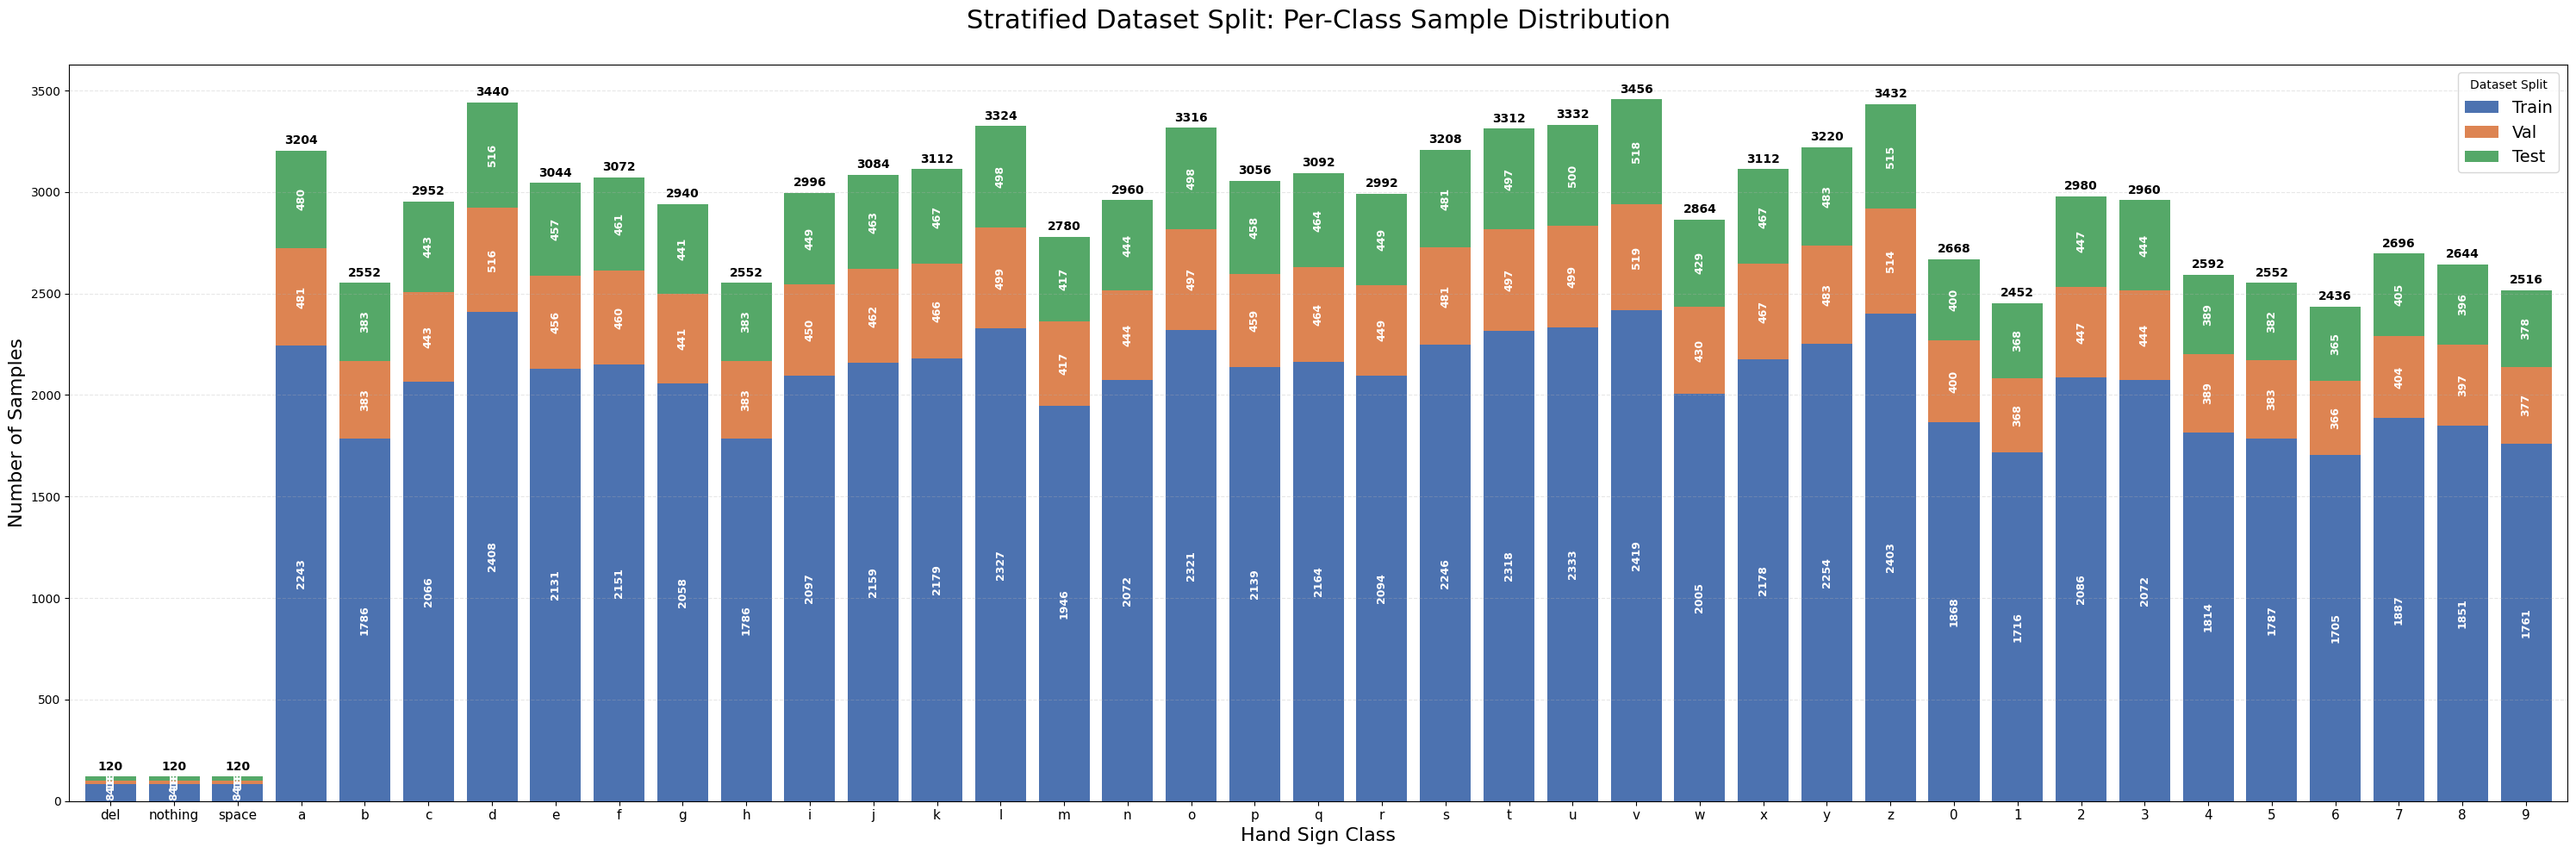

In [52]:
def plot_wide_distribution(train_df, val_df, test_df, label_map, save_path=None):
    # 1. Align counts into a single DataFrame
    df_counts = pd.DataFrame({
        'Train': train_df['label'].value_counts(),
        'Val': val_df['label'].value_counts(),
        'Test': test_df['label'].value_counts()
    }).fillna(0)

    # 2. Reorder (A-Z, 0-9, special)
    order = [label_map[i] for i in sorted(label_map.keys())]
    df_counts = df_counts.reindex(order)

    # 3. Create a VERY wide plot (Width=30, Height=10)
    fig, ax = plt.subplots(figsize=(30, 10))
    
    # Plot stacked vertical bars
    df_counts.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452', '#55A868'], width=0.8)

    # 4. Add numbers inside each segment
    for c in ax.containers:
        # Filter out 0s and rotate text 90 degrees if bars are narrow
        labels = [f'{int(v)}' if v > 0 else '' for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', color='white', 
                     fontsize=9, fontweight='bold', rotation=90)

    # 5. Add total count on top of each bar for quick reference
    totals = df_counts.sum(axis=1)
    for i, total in enumerate(totals):
        ax.text(i, total + 20, f'{int(total)}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10, color='black')

    # Styling
    plt.title('Stratified Dataset Split: Per-Class Sample Distribution', fontsize=22, pad=30)
    plt.xlabel('Hand Sign Class', fontsize=16)
    plt.ylabel('Number of Samples', fontsize=16)
    plt.xticks(rotation=0, fontsize=11) # Keep rotation 0 if width is enough
    plt.legend(title="Dataset Split", fontsize=14, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Execute
plot_wide_distribution(train_df, val_df, test_df, inverse_label_map, save_path='../results/wide_distribution.png')

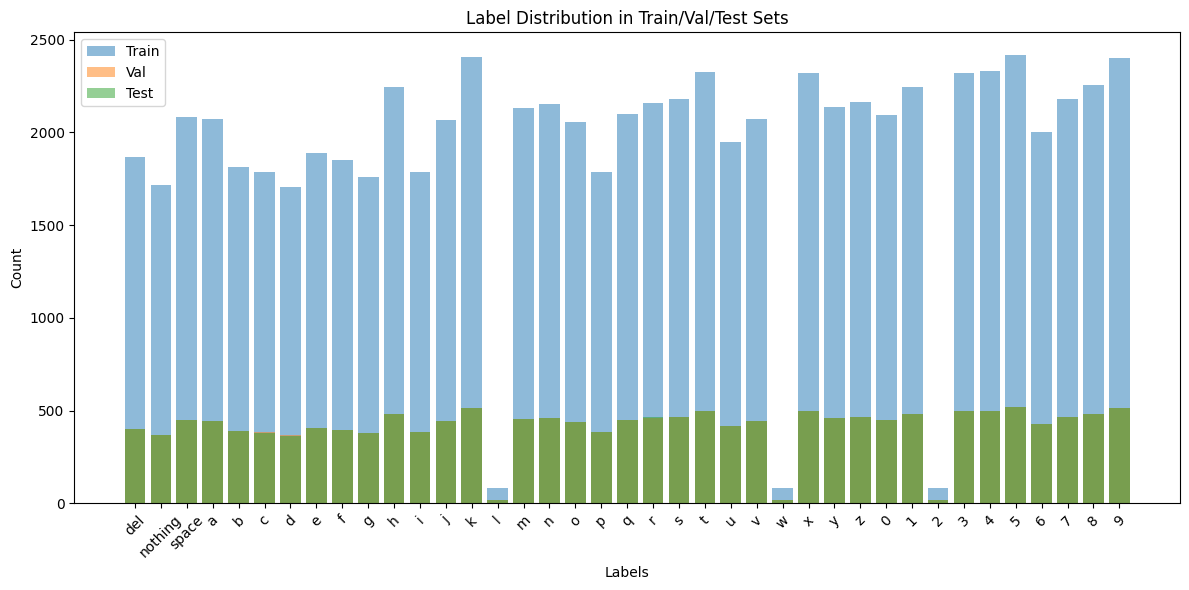

In [53]:
# plot label distribution for train, val, test with sorted labels
def plot_label_distribution(train_df, val_df, test_df, label_map, save_path=None):
    train_counts = train_df['label'].value_counts().sort_index()
    val_counts = val_df['label'].value_counts().sort_index()
    test_counts = test_df['label'].value_counts().sort_index()

    # print("Train label distribution:\n", train_counts)
    # print("Val label distribution:\n", val_counts)
    # print("Test label distribution:\n", test_counts)

    labels = [label_map[idx] for idx in sorted(label_map.keys())]

    plt.figure(figsize=(12, 6))
    plt.bar(labels, train_counts, alpha=0.5, label='Train')
    plt.bar(labels, val_counts, alpha=0.5, label='Val')
    plt.bar(labels, test_counts, alpha=0.5, label='Test')
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.title('Label Distribution in Train/Val/Test Sets')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

plot_label_distribution(train_df, val_df, test_df, inverse_label_map, save_path='../results/label_distribution.png')

In [54]:
# Example usage:
for norm_landmarks, landmarks, label in train_loader:
    print("Normalized landmarks batch shape:", norm_landmarks.shape)  # Should be (batch_size, 21, 3)
    print("Normalized landmarks batch type:", norm_landmarks.dtype)  # Should be torch.float32
    print("Landmarks batch shape:", landmarks.shape)  # Should be (batch_size, 21, 3)
    print("Landmarks batch type:", landmarks.dtype)  # Should be torch.float32
    print("Labels batch shape:", label.shape)        # Should be (batch_size,)
    print("Labels batch type:", label.dtype)        # Should be torch.long
    break

Normalized landmarks batch shape: torch.Size([128, 21, 3])
Normalized landmarks batch type: torch.float32
Landmarks batch shape: torch.Size([128, 21, 3])
Landmarks batch type: torch.float32
Labels batch shape: torch.Size([128])
Labels batch type: torch.int64


## Model Initialization

In [55]:
class HandLandmarkTransformer(nn.Module):
    def __init__(self, num_classes):
        super(HandLandmarkTransformer, self).__init__()
        self.d_model = config['d_model']
        self.num_classes = num_classes
        self.dropout_rate = config['dropout_rate']
        self.num_heads = config['num_heads']
        self.encoder_layers = config['encoder_layers']

        # Input: (Batch, 21, 3) -> Output: (Batch, 21, d_model)
        self.input_proj = nn.Linear(3, self.d_model)

        # Positional encoding
        self.pos_embedding = nn.Parameter(torch.rand(1, 21, self.d_model))

        # Lightweight Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.num_heads, 
            dim_feedforward=self.d_model*4, 
            dropout=self.dropout_rate, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.encoder_layers)

        # Classification Head
        self.fc = nn.Linear(self.d_model, self.num_classes)

    def forward(self, x):
        # x: (Batch, 21, 3)
        x = self.input_proj(x)                 # (B, 21, 128)
        x = x + self.pos_embedding             # Add spatial joint identity
        x = self.transformer_encoder(x)                # Self-Attention across joints
        x = x.mean(dim=1)                      # Global representation
        return self.fc(x)

In [56]:
from torchinfo import summary

model = HandLandmarkTransformer(num_classes=config['num_classes'])
summary(model, input_size=(config['batch_size'], 21, 3))

Layer (type:depth-idx)                        Output Shape              Param #
HandLandmarkTransformer                       [128, 39]                 10,752
├─Linear: 1-1                                 [128, 21, 512]            2,048
├─TransformerEncoder: 1-2                     [128, 21, 512]            --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [128, 21, 512]            3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [128, 21, 512]            3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [128, 21, 512]            3,152,384
├─Linear: 1-3                                 [128, 39]                 20,007
Total params: 9,489,959
Trainable params: 9,489,959
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 809.90
Input size (MB): 0.03
Forward/backward pass size (MB): 242.26
Params size (MB): 25.31
Estimated Total Size (MB): 267.60

## Model Training

In [57]:
weights = [1.0] * config['num_classes']  # Start with equal weights
# First 3 classes are underrepresented, so give them higher weights
weights[:3] = [20.0] * 3
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

In [58]:
classes

array(['del', 'nothing', 'space', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h',
       'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u',
       'v', 'w', 'x', 'y', 'z', '0', '1', '2', '3', '4', '5', '6', '7',
       '8', '9'], dtype=object)

In [59]:
class TransformerTrainer:
    """Trainer for Transformer model."""
    
    def __init__(
        self,
        model: nn.Module,
        device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
        learning_rate: float = 1e-4,
        weight_decay: float = 0.0,
        weights_tensor: torch.Tensor = None,
        landmark_type = 'normalized',  # 'normalized' or 'raw'
        # inverse_label_map: Dict[int, str] = None
    ):
        """
        Initialize trainer.
        
        Args:
            model: Transformer model
            device: Device to train on
            learning_rate: Learning rate
            weight_decay: Weight decay for regularization
        """
        self.model = model.to(device)
        self.device = device
        self.optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.2, patience=3
        )
        if weights_tensor is not None:
            self.criterion = nn.CrossEntropyLoss(weight=weights_tensor)
        else:
            self.criterion = nn.CrossEntropyLoss()
        self.inverse_label_map = inverse_label_map
        self.landmark_type = landmark_type

        print(f"Initialized trainer on device: {device}")
    
    def train_epoch(self, train_loader: DataLoader) -> float:
        """
        Train for one epoch.
        
        Args:
            train_loader: Training data loader
            
        Returns:
            Average training loss
        """
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        
        for normalized_landmarks, landmarks, labels in tqdm(train_loader, desc="Training", leave=False):
            # Get batch data
            if self.landmark_type == 'normalized':
                encoder_input = normalized_landmarks.to(self.device)
            elif self.landmark_type == 'raw':
                encoder_input = landmarks.to(self.device)
            # targets = torch.tensor([self.inverse_label_map[l.item()] for l in labels], dtype=torch.long).to(self.device)
            targets = labels.to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(encoder_input)
            
            # Calculate loss
            loss = self.criterion(outputs, targets)
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            total += targets.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()

        accuracy = correct / total if total > 0 else 0
        print(f"Training Accuracy: {accuracy:.4f}")
        
        return total_loss / len(train_loader), accuracy
    
    def evaluate(self, val_loader: DataLoader) -> Tuple[float, np.ndarray, np.ndarray]:
        """
        Evaluate model on validation/test set.
        
        Args:
            val_loader: Validation data loader
            
        Returns:
            Tuple of (average loss, predictions, true values)
        """
        self.model.eval()
        total_loss = 0.0
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for normalized_landmarks, landmarks, labels in tqdm(val_loader, desc="Evaluating", leave=False):
                if self.landmark_type == 'normalized':
                    encoder_input = normalized_landmarks.to(self.device)
                elif self.landmark_type == 'raw':
                    encoder_input = landmarks.to(self.device)
                # targets = torch.tensor([self.inverse_label_map[l.item()] for l in labels], dtype=torch.long).to(self.device)
                targets = labels.to(self.device)

                outputs = self.model(encoder_input)
                
                loss = self.criterion(outputs, targets)
                total_loss += loss.item()
                
                all_predictions.append(outputs.cpu().numpy())
                all_targets.append(targets.cpu().numpy())
        
        predictions = np.concatenate(all_predictions, axis=0)
        true_values = np.concatenate(all_targets, axis=0)

        accuracy = accuracy_score(true_values, np.argmax(predictions, axis=1))
        print(f"Validation Accuracy: {accuracy:.4f}")
        prec, recall, f1, _ = precision_recall_fscore_support(true_values, np.argmax(predictions, axis=1), average='weighted')
        print(f"Precision: {prec:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
        
        return total_loss / len(val_loader), predictions, true_values, accuracy
    
    def fit(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        epochs: int = 50,
        early_stopping_patience: int = 10,
        save_path: str = None
    ) -> Dict[str, List[float]]:
        """
        Train the model.
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            epochs: Number of epochs
            early_stopping_patience: Patience for early stopping
            save_path: Path to save best model
            
        Returns:
            Dictionary with training history
        """
        history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': []
        }
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            
            # Validate
            val_loss, _, _, val_acc = self.evaluate(val_loader)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            
            # Update learning rate
            self.scheduler.step(val_loss)
            
            print(f"Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Learning Rate: {self.optimizer.param_groups[0]['lr']}")
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                
                if save_path:
                    torch.save(self.model.state_dict(), save_path)
                    print(f"Saved best model to {save_path}")
            else:
                patience_counter += 1
                
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch + 1} epochs")
                break
        
        # Load best model
        if save_path:
            self.model.load_state_dict(torch.load(save_path))
            print("Loaded best model")
        
        return history
    
    def predict(self, test_loader: DataLoader) -> np.ndarray:
        """
        Make predictions on test set.
        
        Args:
            test_loader: Test data loader
            
        Returns:
            Predictions array
        """
        _, predictions, _ = self.evaluate(test_loader)
        return predictions

In [60]:
for norm_landmarks, landmarks, labels in tqdm(train_loader, desc="Training", leave=False):
    # targets = torch.tensor([inverse_label_map[l.item()] for l in labels], dtype=torch.long).to(self.device)
    for l in labels:
        label_index = l.item() 
        
        # Now you can use it to look up the original character in your inverse map
        # Note: Use idx_to_label here if you want to see 'a', 'b', etc.
        print(f"Index: {label_index}")
        print(f"Character: {inverse_label_map[label_index]}") 
        break
    break

Training:   0%|          | 0/587 [00:00<?, ?it/s]

Index: 33
Character: 4


In [61]:
def plot_loss(history, save_path):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Hand Landmark Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (CrossEntropy)')
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()

def plot_accuracy(history, save_path):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Hand Landmark Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()

In [62]:
checkpoint_path_norm = '../checkpoints/best_model_normalized.pth'
checkpoint_path_raw = '../checkpoints/best_model_raw.pth'

In [ ]:
model = HandLandmarkTransformer(num_classes=config['num_classes'])
model_raw = HandLandmarkTransformer(num_classes=config['num_classes'])
normalized_landmarks_trainer = TransformerTrainer(
    model=model, 
    device=device, 
    learning_rate=config['learning_rate'], 
    weights_tensor=weights_tensor, 
    landmark_type='normalized'
)
raw_landmarks_trainer = TransformerTrainer(
    model=model_raw, 
    device=device, 
    learning_rate=config['learning_rate'], 
    weights_tensor=weights_tensor, 
    landmark_type='raw'
)

Initialized trainer on device: cuda
Initialized trainer on device: cuda


### Train Model with Normalized & Scaled Landmarks

In [184]:
history = normalized_landmarks_trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config['num_epochs'],
    early_stopping_patience=10,
    save_path=checkpoint_path_norm
)


Epoch 1/30


Training Accuracy: 0.5621


Validation Accuracy: 0.8030
Precision: 0.8227, Recall: 0.8030, F1-Score: 0.7967
Train Loss: 1.521386, Val Loss: 0.642004, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model_normalized.pth

Epoch 2/30


Training Accuracy: 0.8236


Validation Accuracy: 0.8615
Precision: 0.8719, Recall: 0.8615, F1-Score: 0.8625
Train Loss: 0.571463, Val Loss: 0.463490, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model_normalized.pth

Epoch 3/30


...

Validation Accuracy: 0.9769
Precision: 0.9770, Recall: 0.9769, F1-Score: 0.9769
Train Loss: 0.034420, Val Loss: 0.123863, Learning Rate: 2e-05

Epoch 29/30


Training Accuracy: 0.9893


Validation Accuracy: 0.9782
Precision: 0.9784, Recall: 0.9782, F1-Score: 0.9782
Train Loss: 0.033004, Val Loss: 0.120349, Learning Rate: 4.000000000000001e-06

Epoch 30/30


Training Accuracy: 0.9920


Validation Accuracy: 0.9792
Precision: 0.9793, Recall: 0.9792, F1-Score: 0.9792
Train Loss: 0.026294, Val Loss: 0.117477, Learning Rate: 4.000000000000001e-06
Saved best model to ../checkpoints/best_model_normalized.pth
Loaded best model


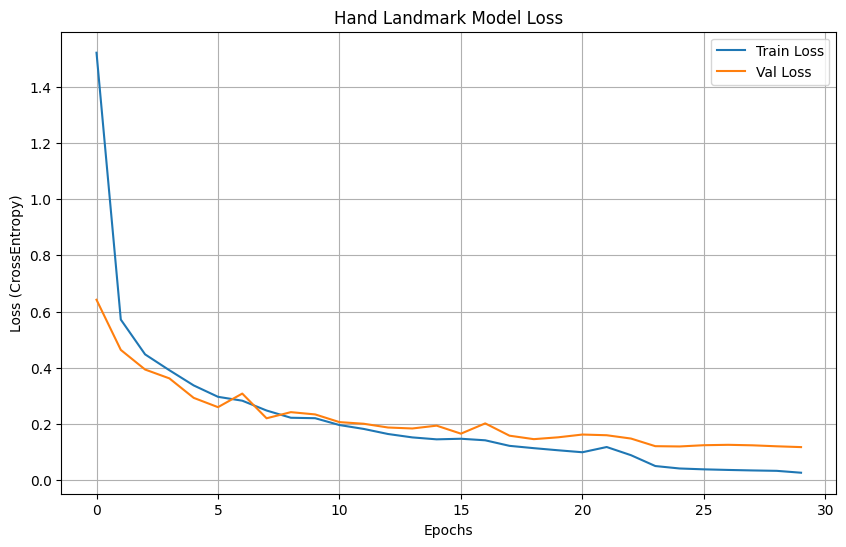

In [185]:
plot_loss(history, save_path='../results/transformer_loss_norm.png')

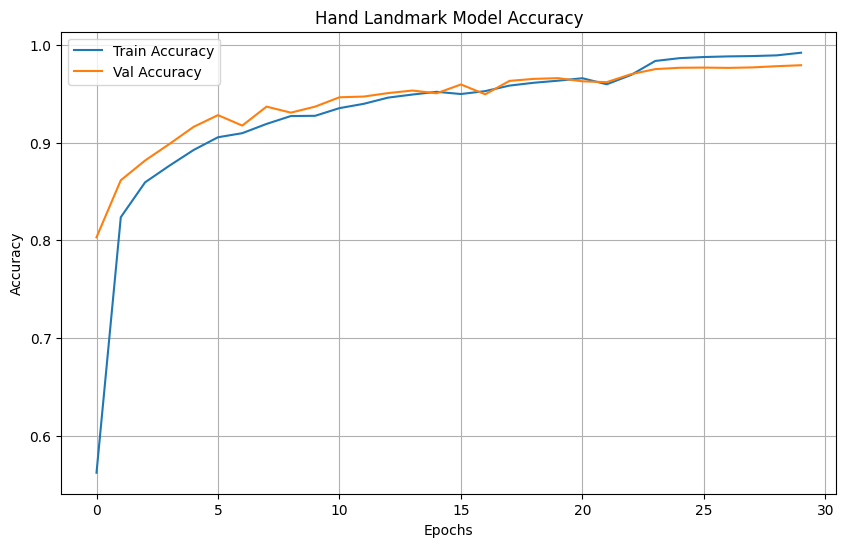

In [186]:
plot_accuracy(history, save_path='../results/transformer_acc_norm.png')

### Train Model with Raw Landmarks

In [187]:
history_raw = raw_landmarks_trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config['num_epochs'],
    early_stopping_patience=10,
    save_path=checkpoint_path_raw
)


Epoch 1/30


Training Accuracy: 0.2397


Validation Accuracy: 0.4702
Precision: 0.4763, Recall: 0.4702, F1-Score: 0.4448
Train Loss: 2.637050, Val Loss: 1.718962, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model_raw.pth

Epoch 2/30


Training Accuracy: 0.6022


Validation Accuracy: 0.7265
Precision: 0.7576, Recall: 0.7265, F1-Score: 0.7294
Train Loss: 1.279729, Val Loss: 0.858920, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model_raw.pth

Epoch 3/30


...

Validation Accuracy: 0.9753
Precision: 0.9754, Recall: 0.9753, F1-Score: 0.9752
Train Loss: 0.040890, Val Loss: 0.108652, Learning Rate: 2e-05
Saved best model to ../checkpoints/best_model_raw.pth

Epoch 29/30


Training Accuracy: 0.9877


Validation Accuracy: 0.9751
Precision: 0.9752, Recall: 0.9751, F1-Score: 0.9751
Train Loss: 0.040460, Val Loss: 0.111648, Learning Rate: 2e-05

Epoch 30/30


Training Accuracy: 0.9884


Validation Accuracy: 0.9745
Precision: 0.9747, Recall: 0.9745, F1-Score: 0.9744
Train Loss: 0.038370, Val Loss: 0.110424, Learning Rate: 2e-05
Loaded best model


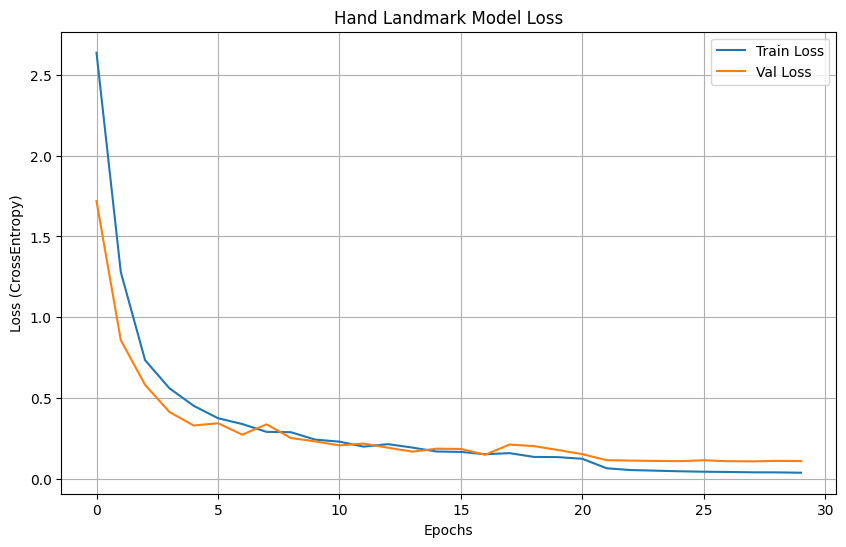

In [188]:
plot_loss(history_raw, save_path='../results/transformer_loss_raw.png')

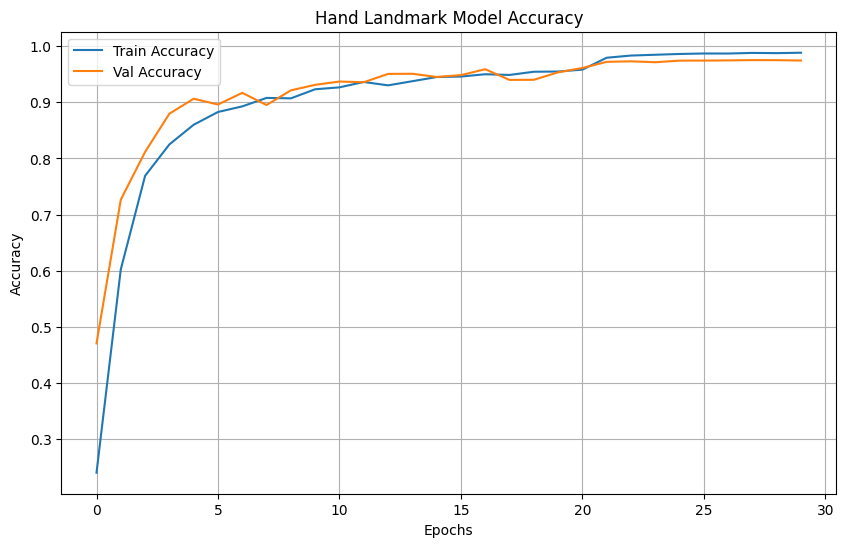

In [189]:
plot_accuracy(history_raw, save_path='../results/transformer_acc_raw.png')

## Model Inference

### Inference with Normed & Scaled Trained model

In [ ]:
# Load best model for evaluation
model = HandLandmarkTransformer(num_classes=config['num_classes'])
model.load_state_dict(torch.load(checkpoint_path_norm))
model.to(device)
normalized_landmarks_trainer = TransformerTrainer(
    model=model, 
    device=device, 
    learning_rate=config['learning_rate'], 
    weights_tensor=weights_tensor, 
    landmark_type='normalized'
)
loss, predictions, true_values, accuracy = normalized_landmarks_trainer.evaluate(test_loader)

Validation Accuracy: 0.9806
Precision: 0.9807, Recall: 0.9806, F1-Score: 0.9806


In [213]:
print(f"Test Loss: {loss:.6f}")

Test Loss: 0.114027


In [214]:
# 1. Convert logits to class indices
# predictions shape: (N, 39) -> pred_indices shape: (N,)
pred_indices = np.argmax(predictions, axis=1)

# 2. Calculate simple accuracy
correct_predictions = np.sum(pred_indices == true_values)
total_samples = len(true_values)
accuracy = correct_predictions / total_samples

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Correct: {correct_predictions} / {total_samples}")

Test Accuracy: 98.06%
Correct: 15777 / 16089


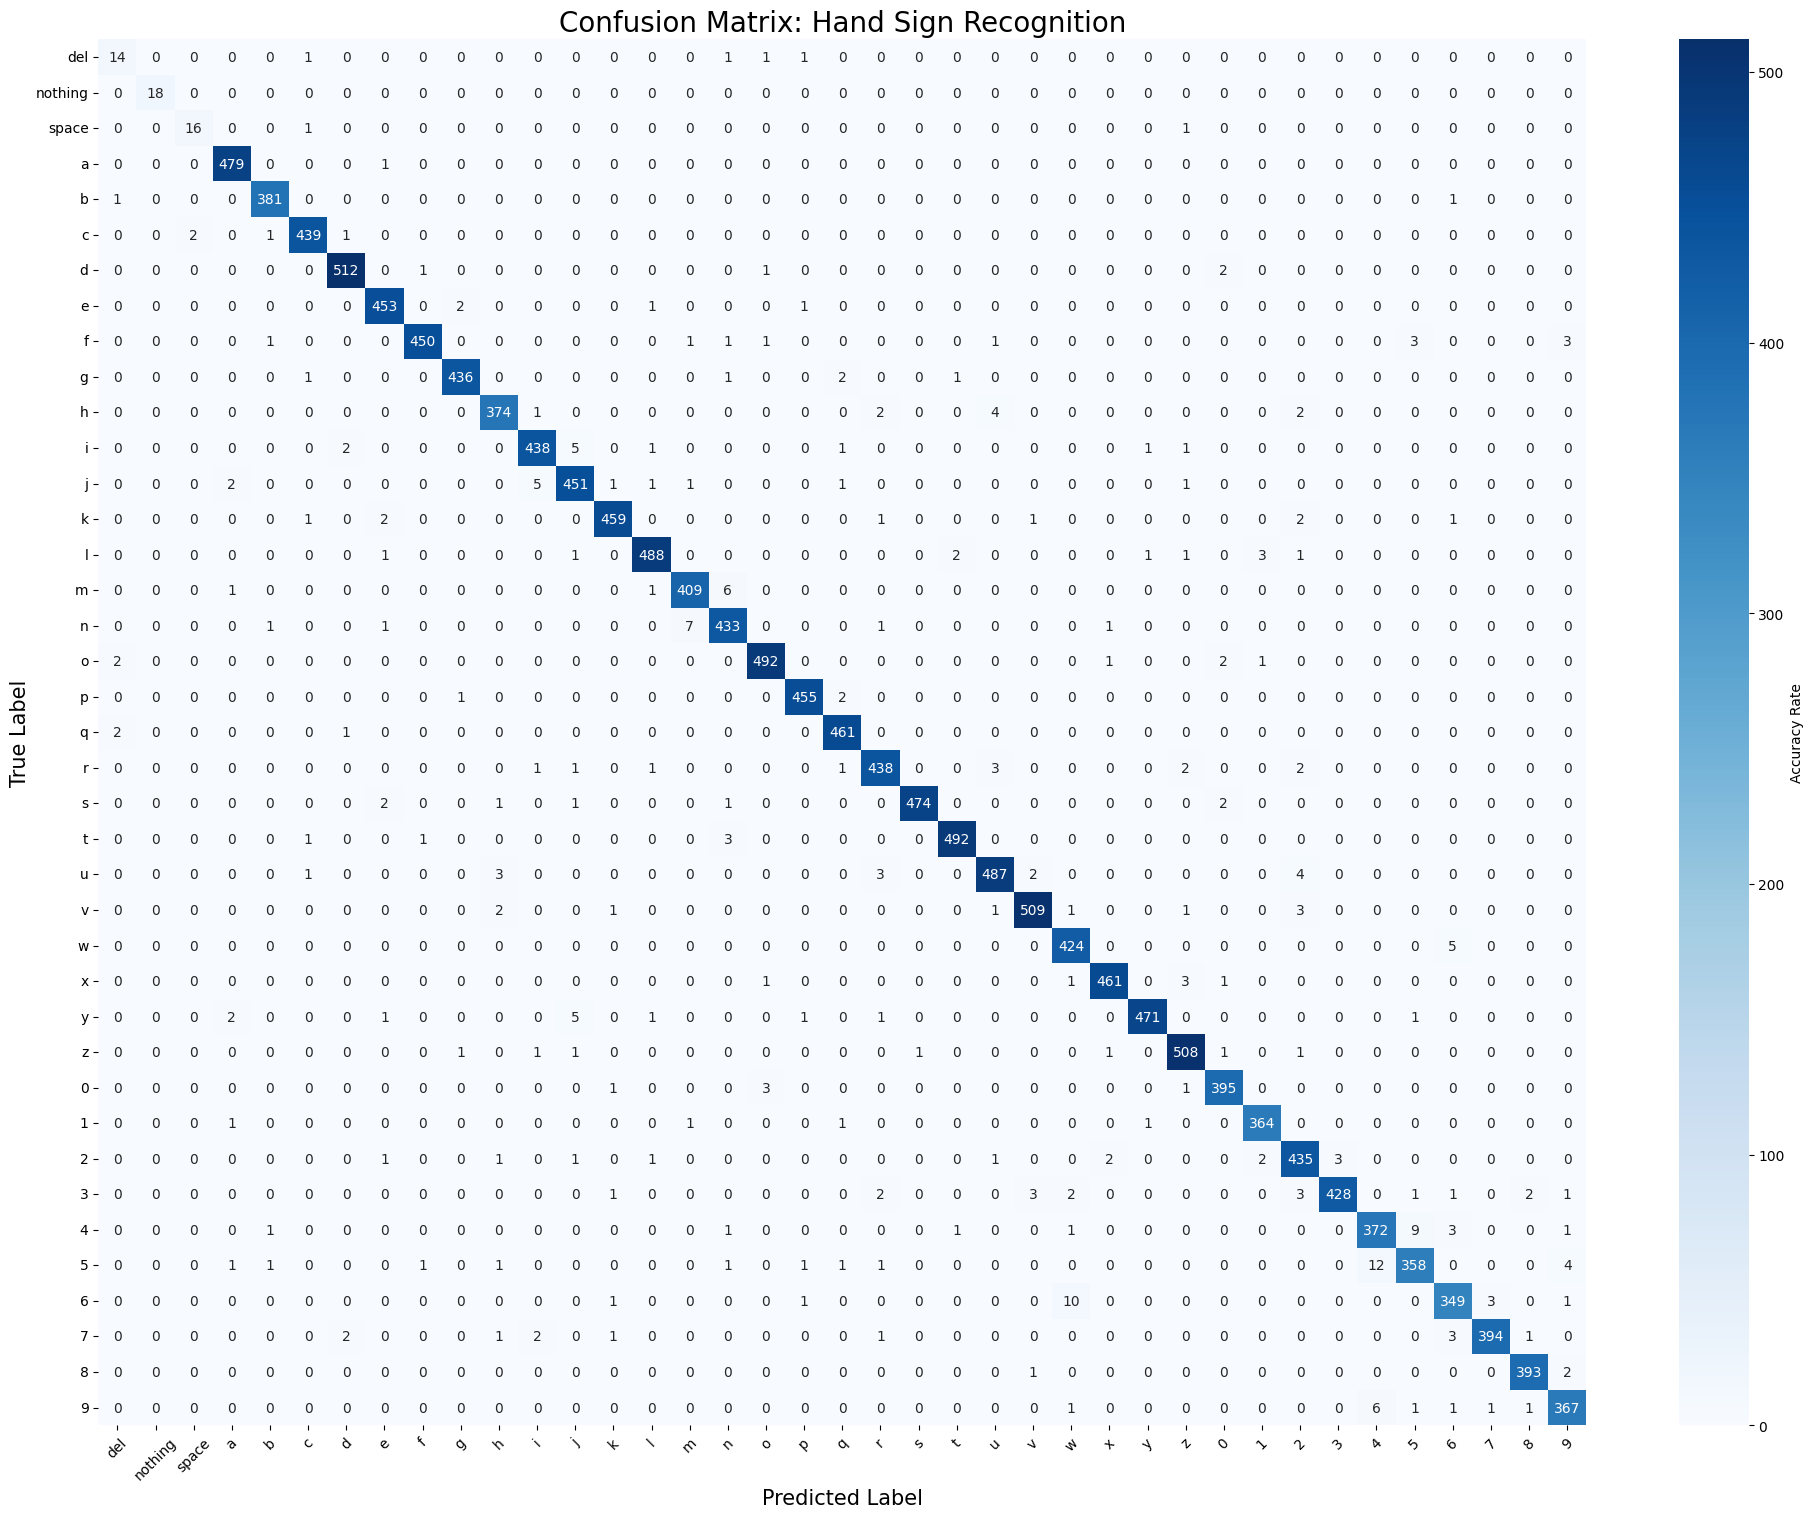

In [215]:
def plot_styled_confusion_matrix(true_values, predictions, label_map, save_path=None):
    # 1. Convert logits to class indices
    pred_indices = np.argmax(predictions, axis=1)
    
    # 2. Get the list of names in the correct order
    # label_map keys are usually '0', '1', ... 'A', 'B', ... 'space'
    class_names = list(label_map.keys())
    
    # 3. Compute normalized confusion matrix
    # 'true' normalization shows the % of correct hits per class
    cm = confusion_matrix(true_values, pred_indices)
    
    # 4. Plotting
    plt.figure(figsize=(24, 18)) # Big enough for 39 classes
    sns.heatmap(
        cm, 
        annot=True, # Set to True if you want the numbers, but it's messy with 39 classes
        fmt='d', 
        cmap='Blues', # Or 'Purples' to match your reference
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar_kws={'label': 'Accuracy Rate'}
    )
    
    plt.title('Confusion Matrix: Hand Sign Recognition', fontsize=20)
    plt.xlabel('Predicted Label', fontsize=15)
    plt.ylabel('True Label', fontsize=15)
    plt.xticks(rotation=45)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# Call the function
plot_styled_confusion_matrix(true_values, predictions, label_map, save_path='../results/transformer_norm_confusion_matrix.png')

In [228]:
# visualize 3 images with their predicted and true labels, can choose to visualize only correct or incorrect predictions based on a parameter
def visualize_predictions(test_loader, predictions, true_values, label_map, num_samples=3, correct_predict=False):
    pred_indices = np.argmax(predictions, axis=1)
    indices = np.arange(len(true_values))
    
    if correct_predict:
        selected_indices = indices[pred_indices == true_values]
    else:
        selected_indices = indices[pred_indices != true_values]
    
    if len(selected_indices) == 0:
        print("No samples to display based on the criteria.")
        return
    
    selected_indices = np.random.choice(selected_indices, min(num_samples, len(selected_indices)), replace=False)
    
    for idx in selected_indices:
        img_path = f"../dataset/images/{test_loader.dataset.labels_df.iloc[idx]['image']}"
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        true_label = label_map[true_values[idx]]
        pred_label = label_map[pred_indices[idx]]
        
        plt.figure(figsize=(4, 4))
        plt.imshow(img_rgb)
        plt.title(f"True: {true_label} | Pred: {pred_label}", fontsize=12)
        plt.axis('off')
        plt.show()

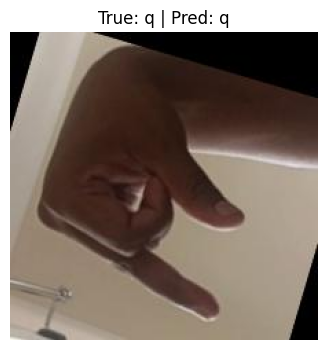

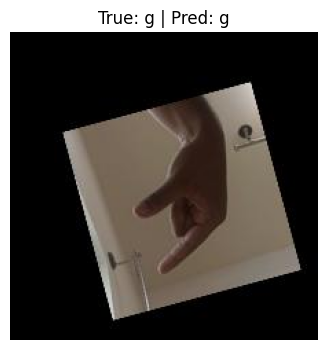

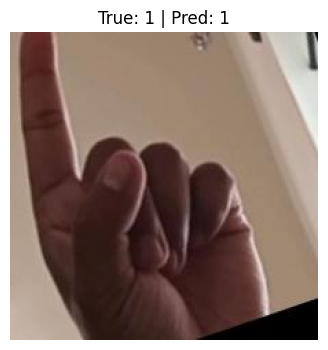

In [230]:
visualize_predictions(test_loader, predictions, true_values, inverse_label_map, num_samples=3, correct_predict=True)

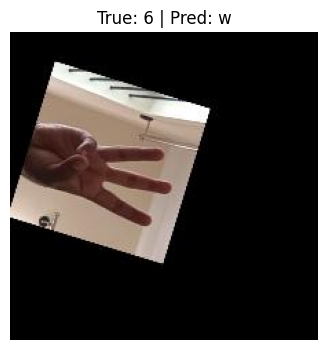

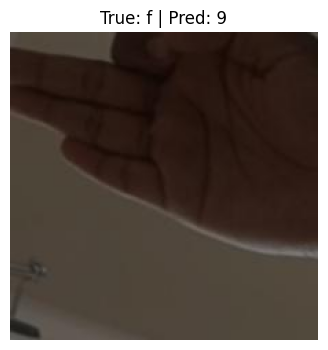

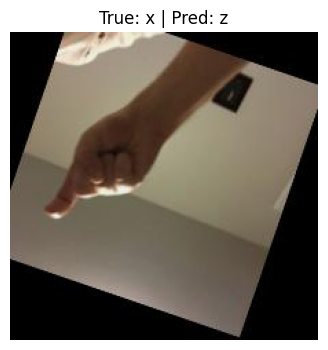

In [229]:
visualize_predictions(test_loader, predictions, true_values, inverse_label_map, num_samples=3, correct_predict=False)

### Inference with Raw Landmarks Trained model

In [ ]:
# Load best model for evaluation
model = HandLandmarkTransformer(num_classes=config['num_classes'])
model.load_state_dict(torch.load(checkpoint_path_raw))
model.to(device)
raw_landmarks_trainer = TransformerTrainer(
    model=model, 
    device=device, 
    learning_rate=config['learning_rate'], 
    weights_tensor=weights_tensor, 
    landmark_type='raw'
)
loss, predictions, true_values, accuracy = raw_landmarks_trainer.evaluate(test_loader)

Validation Accuracy: 0.9758
Precision: 0.9760, Recall: 0.9758, F1-Score: 0.9758


In [217]:
print(f"Test Loss: {loss:.6f}")

Test Loss: 0.129395


In [218]:
# 1. Convert logits to class indices
# predictions shape: (N, 39) -> pred_indices shape: (N,)
pred_indices = np.argmax(predictions, axis=1)

# 2. Calculate simple accuracy
correct_predictions = np.sum(pred_indices == true_values)
total_samples = len(true_values)
accuracy = correct_predictions / total_samples

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Correct: {correct_predictions} / {total_samples}")

Test Accuracy: 97.58%
Correct: 15700 / 16089


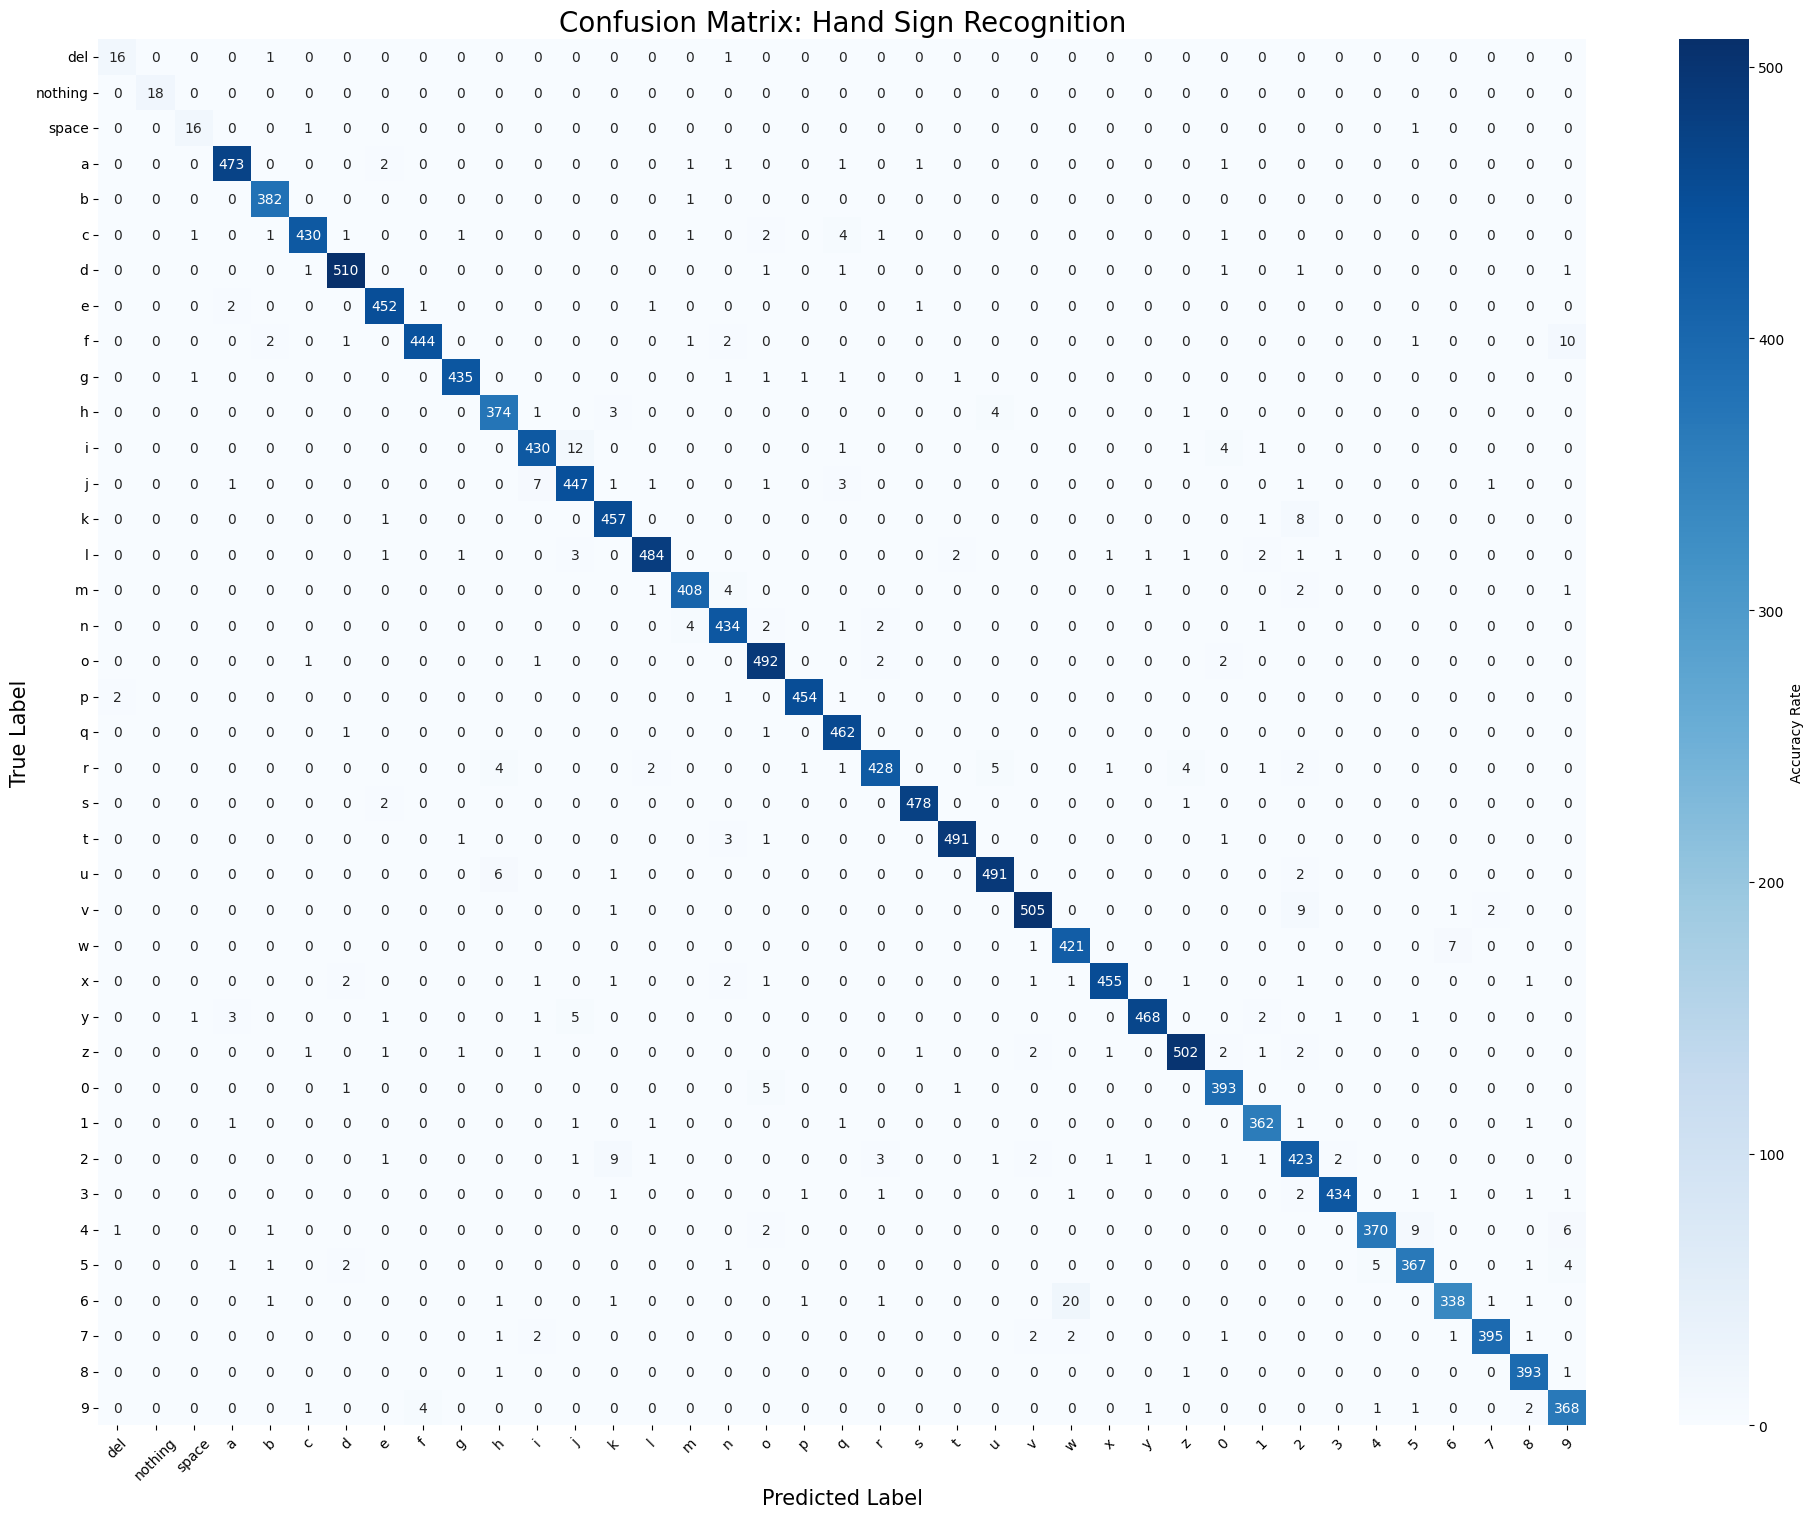

In [219]:
plot_styled_confusion_matrix(true_values, predictions, label_map, save_path='../results/transformer_raw_confusion_matrix.png')

## Try using the model with OpenCV camera

In [31]:
# try using the model with opencv to capture real-time webcam feed and predict the hand sign being shown
def real_time_prediction(model, label_map, detector, device):
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return
    
    model.eval()
    
    with torch.no_grad():
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Error: Failed to capture frame.")
                break
            
            # Convert to RGB for MediaPipe
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            
            results = detector.detect(img_mp)
            
            if results.hand_landmarks:
                landmarks = []
                for lm in results.hand_landmarks[0]:
                    landmarks.append([lm.x, lm.y, lm.z])
                landmarks = np.array(landmarks)
                normalized_landmarks = normalize_landmarks(landmarks)
                
                input_tensor = torch.tensor(normalized_landmarks, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 21, 3)
                output = model(input_tensor)
                pred_index = output.argmax(dim=1).item()
                pred_label = label_map[pred_index]
                
                # Draw landmarks and prediction on the frame
                for lm in results.hand_landmarks[0]:
                    x = int(lm.x * frame.shape[1])
                    y = int(lm.y * frame.shape[0])
                    cv2.circle(frame, (x, y), 5, (0, 255, 0), -1)
                
                cv2.putText(frame, f"Pred: {pred_label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
                            1, (255, 0, 0), 2, cv2.LINE_AA)
            
            cv2.imshow('Real-Time Hand Sign Recognition', frame)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    
    cap.release()
    cv2.destroyAllWindows()

In [32]:
model = HandLandmarkTransformer(num_classes=config['num_classes'])
model.load_state_dict(torch.load(checkpoint_path_norm))
model.to(device)
real_time_prediction(model, inverse_label_map, detector, device)